Linear Regression

In [490]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import plotly.express as px

In [492]:
# Example data
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])  # Predictor variables
y = np.array([5, 7, 9, 11])  # Target variable

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Get coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Make predictions
predictions = model.predict(X)
print("Predictions:", predictions)

Coefficients: [1. 1.]
Intercept: 2.0000000000000018
Predictions: [ 5.  7.  9. 11.]


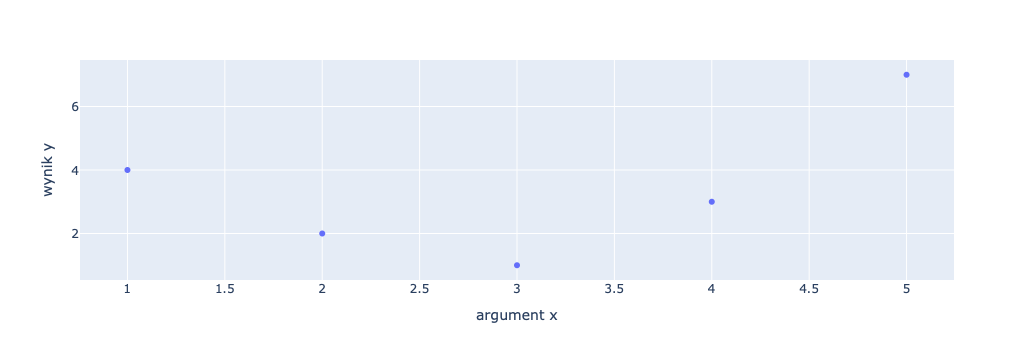

In [494]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([4, 2, 1, 3, 7])
px.scatter(x=x, y=y, labels={"x": "argument x", "y": "wynik y"})

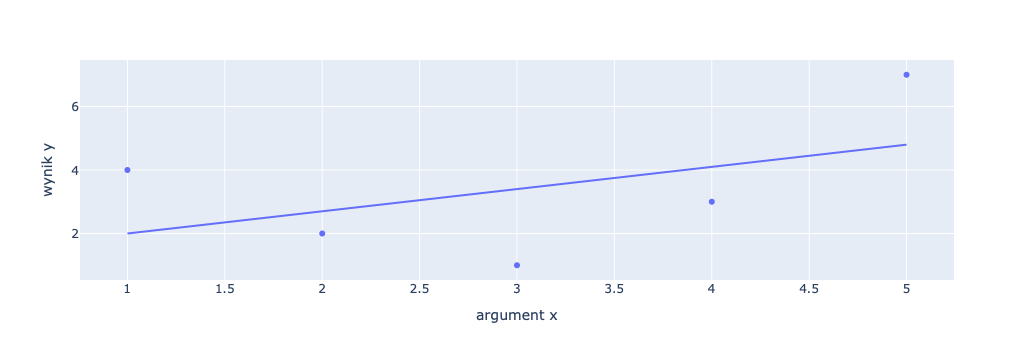

In [157]:
X = x[:, np.newaxis]
model = LinearRegression().fit(X, y)
yfit = model.predict(X)
fig = px.scatter(x=x, y=y, labels={"x": "argument x", "y": "wynik y"})
fig.add_traces(px.line(x=x, y=yfit).data)
fig.show()

In [159]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3, include_bias=False)
X2 = poly.fit_transform(X)
print(X2)

[[  1.   1.   1.]
 [  2.   4.   8.]
 [  3.   9.  27.]
 [  4.  16.  64.]
 [  5.  25. 125.]]


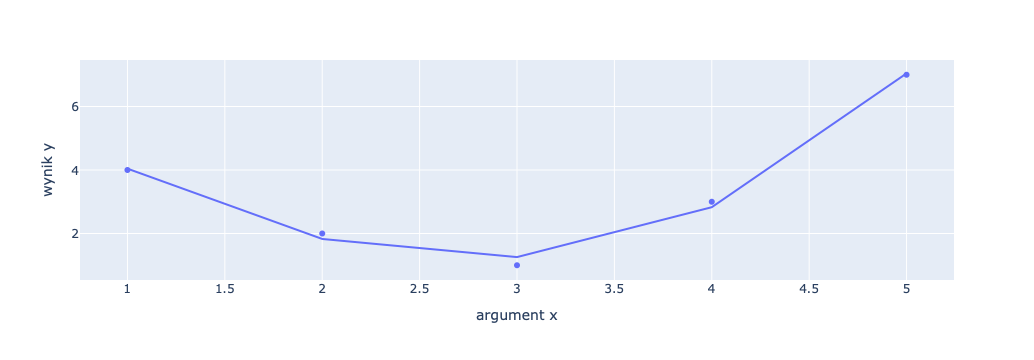

In [161]:
model = LinearRegression().fit(X2, y)
yfit = model.predict(X2)
fig = px.scatter(x=x, y=y, labels={"x": "argument x", "y": "wynik y"})
fig.add_traces(px.line(x=x, y=yfit).data)
fig.show()

In [163]:
X = np.array([[ nan, 0, 3],
[ 3, 7, 9 ],
[ 3, 5, 2 ],
[ 4, nan, 6 ],
[ 8, 8, 1 ]])
y = np.array([14, 16, -1, 8, -5])

In [165]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='mean')
X2 = imp.fit_transform(X)
X2

array([[4.5, 0. , 3. ],
       [3. , 7. , 9. ],
       [3. , 5. , 2. ],
       [4. , 5. , 6. ],
       [8. , 8. , 1. ]])

In [167]:
model = LinearRegression().fit(X2, y)
model.predict(X2)

array([13.14869292, 14.3784627 , -1.15539732, 10.96606197, -5.33782027])

In [169]:
from sklearn.pipeline import make_pipeline
model = make_pipeline(SimpleImputer(strategy='mean'),
PolynomialFeatures(degree=2),
LinearRegression())

In [171]:
model.fit(X, y) # tablica X z brakującymi wartościami z poprzedniego przykładu
print(y)
print(model.predict(X))

[14 16 -1  8 -5]
[14. 16. -1.  8. -5.]


Prosta regresja liniowa

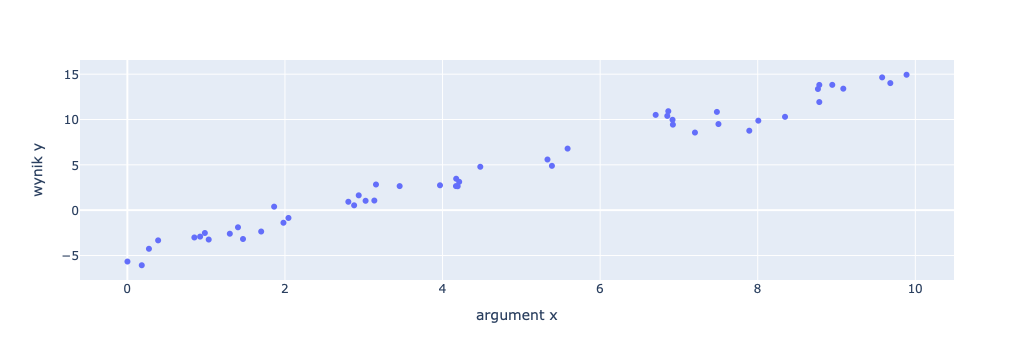

In [174]:
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = 2 * x - 5 + rng.randn(50)
px.scatter(x=x, y=y, labels={"x": "argument x", "y": "wynik y"})

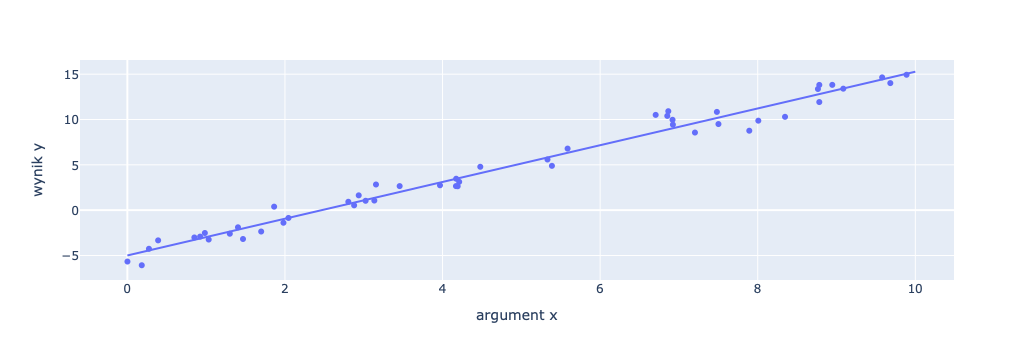

In [176]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)
model.fit(x[:, np.newaxis], y)
xfit = np.linspace(0, 10, 1000)
yfit = model.predict(xfit[:, np.newaxis])
fig = px.scatter(x=x, y=y, labels={"x": "argument x", "y": "wynik y"})
fig.add_traces(px.line(x=xfit, y=yfit).data)
fig.show()

In [178]:
print("Współczynnik nachylenia: ", model.coef_[0])
print("Wyraz wolny: ", model.intercept_)

Współczynnik nachylenia:  2.027208810360696
Wyraz wolny:  -4.9985770855532055


In [180]:
rng = np.random.RandomState(1)
X = 10 * rng.rand(100, 3)
y = 0.5 + np.dot(X, [1.5, -2., 1.])
model.fit(X, y)
print(model.intercept_)
print(model.coef_)

0.5000000000000121
[ 1.5 -2.   1. ]


Regresja funkcjami bazowymi

In [183]:
from sklearn.preprocessing import PolynomialFeatures
x = np.array([2, 3, 4])
poly = PolynomialFeatures(3, include_bias=False)
poly.fit_transform(x[:, None])

array([[ 2.,  4.,  8.],
       [ 3.,  9., 27.],
       [ 4., 16., 64.]])

In [185]:
from sklearn.pipeline import make_pipeline
poly_model = make_pipeline(PolynomialFeatures(7),
LinearRegression())

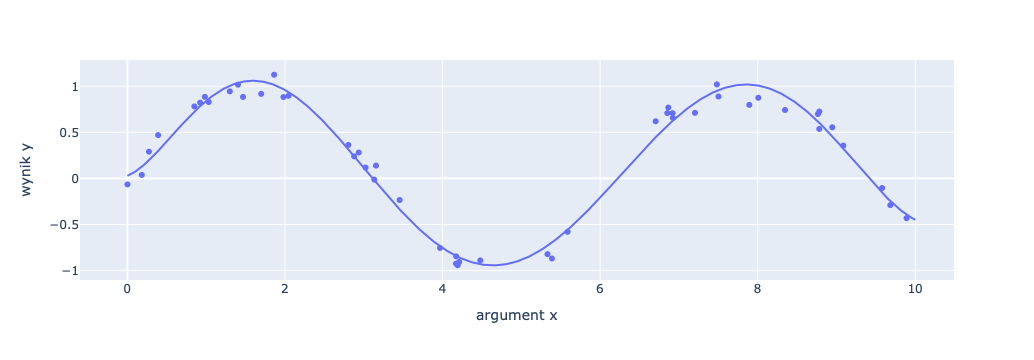

In [187]:
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = np.sin(x) + 0.1 * rng.randn(50)
poly_model.fit(x[:, np.newaxis], y)
yfit = poly_model.predict(xfit[:, np.newaxis])
fig = px.scatter(x=x, y=y, labels={"x": "argument x", "y": "wynik y"})
fig.add_traces(px.line(x=xfit, y=yfit).data)
fig.show()

Gaussowskie funkcje bazowe

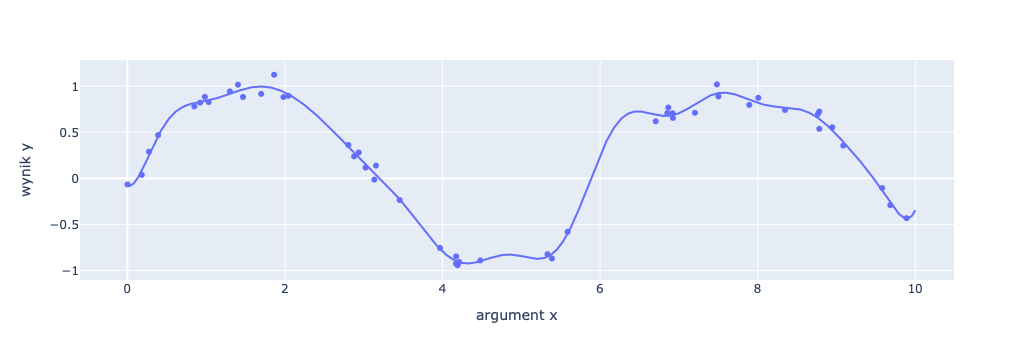

In [190]:
from sklearn.base import BaseEstimator, TransformerMixin
class GaussianFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, N, width_factor=2.0):
        self.N = N
        self.width_factor = width_factor
    @staticmethod
    def _gauss_basis(x, y, width, axis=None):
        arg = (x - y) / width
        return np.exp(-0.5 * np.sum(arg ** 2, axis))
    def fit(self, X, y=None):
# Tworzę N centrów rozmieszczonych w całym zakresie danych
        self.centers_ = np.linspace(X.min(), X.max(), self.N)
        self.width_ = self.width_factor*(self.centers_[1]-self.centers_[0])
        return self
    def transform(self, X):
        return self._gauss_basis(X[:, :, np.newaxis], self.centers_,
        self.width_, axis=1)

gauss_model = make_pipeline(GaussianFeatures(20),
LinearRegression())
gauss_model.fit(x[:, np.newaxis], y)
yfit = gauss_model.predict(xfit[:, np.newaxis])
fig = px.scatter(x=x, y=y, labels={"x": "argument x", "y": "wynik y"})
fig.add_traces(px.line(x=xfit, y=yfit).data)
fig.show()

Regularyzacja

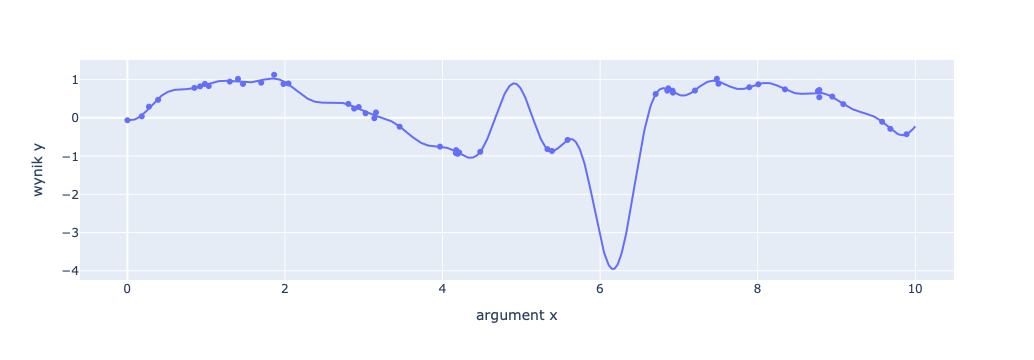

In [193]:
model = make_pipeline(GaussianFeatures(30),
LinearRegression())
model.fit(x[:, np.newaxis], y)
fig = px.scatter(x=x, y=y, labels={"x": "argument x", "y": "wynik y"})
fig.add_traces(px.line(x=xfit, y=model.predict(xfit[:, np.newaxis])).data)
fig.show()

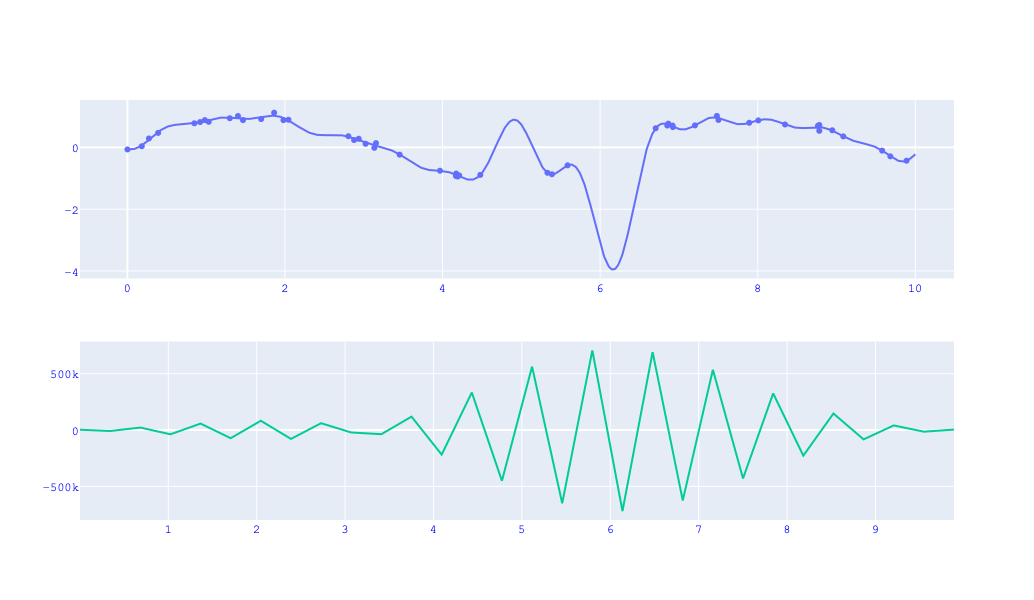

In [195]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

def basis_plot(model, title=None):
    fig = make_subplots(rows=2, cols=1)
    model.fit(x[:, np.newaxis], y)

    fig.append_trace(go.Scatter(x=x, y=y, mode='markers', showlegend=False), row=1, col=1)
    fig.add_traces(px.line(x=xfit, y=model.predict(xfit[:, np.newaxis])).data)
        
    fig.append_trace(go.Scatter(x=model.steps[0][1].centers_, y=model.steps[1][1].coef_, showlegend=False), row=2, col=1, )
    
    fig.update_layout(
        height=600, width=600, 
        title_text=title,
        font_family="Courier New",
        font_color="blue",
        title_font_family="Arial",
        title_font_color="red",
        legend_title_font_color="green")
    fig.show()
    
model = make_pipeline(GaussianFeatures(30), LinearRegression())
basis_plot(model)

Regresja grzbietowa (regularyzacja L2)

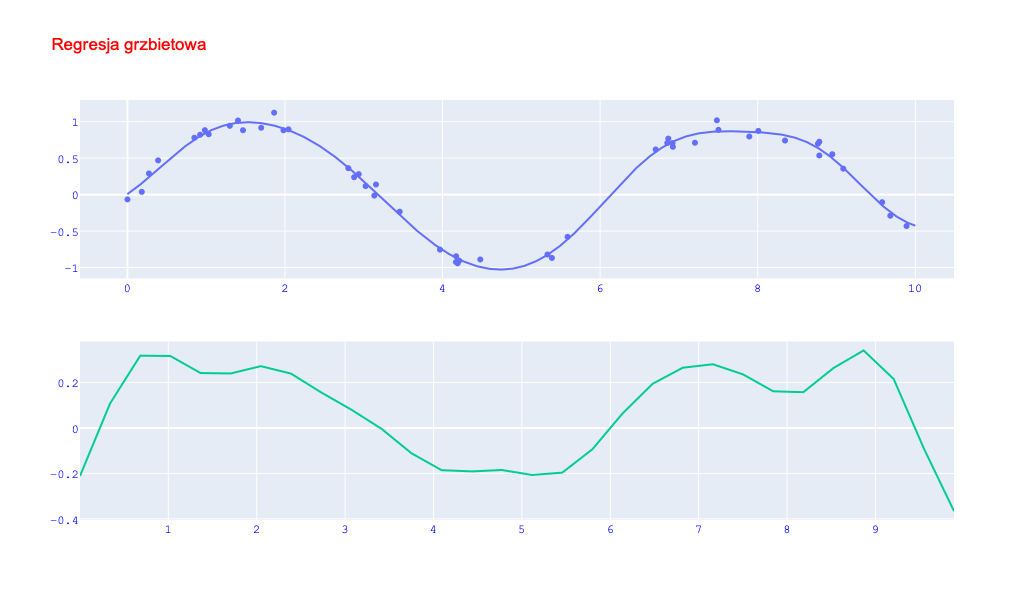

In [198]:
from sklearn.linear_model import Ridge
model = make_pipeline(GaussianFeatures(30), Ridge(alpha=0.1))
basis_plot(model, title='Regresja grzbietowa')

Regresja lasso (regularyzacja L1)

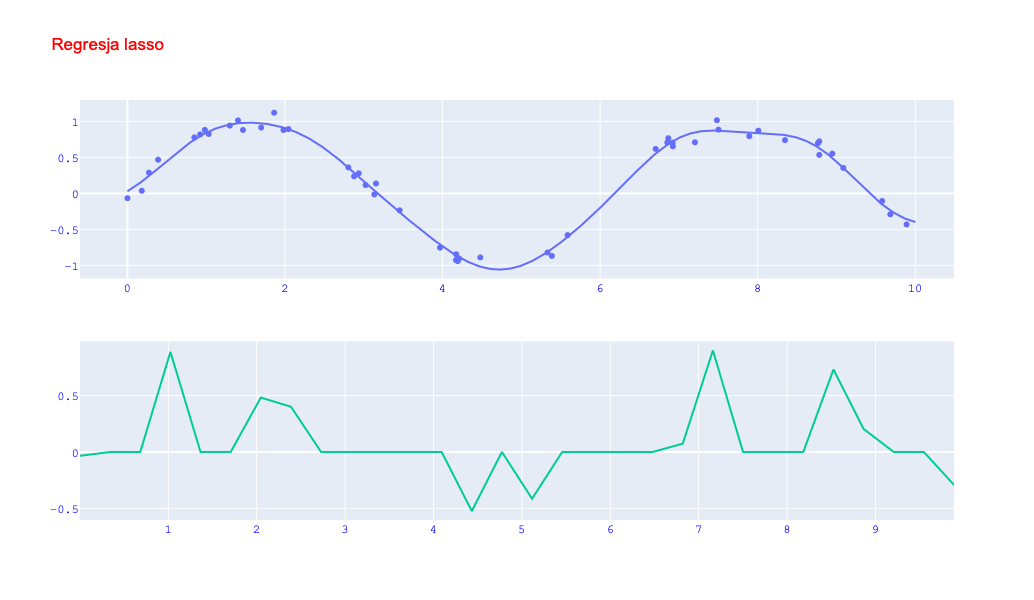

In [201]:
from sklearn.linear_model import Lasso
model = make_pipeline(GaussianFeatures(30),
Lasso(alpha=0.001, max_iter=2000))
basis_plot(model, title='Regresja lasso')